In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_squared_error,mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
df = pd.read_csv("BBDD_100K/ratings.csv")

indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
matriz_usuario_pelicula=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
print(matriz_usuario_pelicula.head())


movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     N

In [3]:
def normalizar_datos(matriz_escasez):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_escasez.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy

matriz_normalizada = normalizar_datos(matriz_usuario_pelicula)
print(matriz_normalizada.head(20))

movieId    1         2         3         4         5         6         7       \
userId                                                                          
1       -0.458937  0.000000 -0.458937  0.000000  0.000000 -0.458937  0.000000   
2        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
5        0.371391  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
6        0.000000  0.596225  1.773677 -0.581226  1.773677  0.596225  0.596225   
7        0.958138  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
8        0.000000  0.442374  0.000000  0.000000  0.000000  0.000000  0.000000   
9        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
10       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
11       0.000000  0.000000 

In [4]:
def reescalar_predicciones(predicciones_normalizadas, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_usuario_pelicula.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_usuario_pelicula.std(axis=1, skipna=True)
    
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_usuario_pelicula.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas



In [5]:
matriz_reescalada_original = reescalar_predicciones(matriz_normalizada, matriz_usuario_pelicula)
matriz_reescalada_original.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Determinar la mejor K

Método del Codo: Evalúa la inercia (suma de las distancias cuadradas de las muestras a su centroide más cercano).

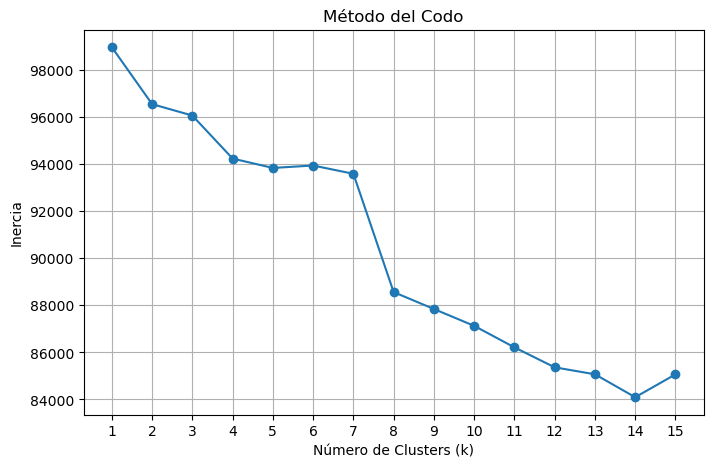

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def metodo_del_codo(matriz, max_k=15):
    #Calcula y guarda el metodo del codo para diferentes valores de k.
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(matriz)
        inercia.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.title('Método del Codo')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inercia')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

metodo_del_codo(matriz_normalizada)


Observando la curva, parece que el "codo" ocurre alrededor de k = 8, donde la disminución de la inercia se vuelve menos pronunciada. Esto sugiere que 8 clústeres podría ser un valor razonable.

Silhouette Score: Mide qué tan cerca están los puntos de su clúster en comparación con otros clústeres.\
Es otra forma de mirar la k óptima, pero en este caso estamos teniendo en cuenta las distáncias, mientras que el método del Codo no se tienen en cuenta las distancias

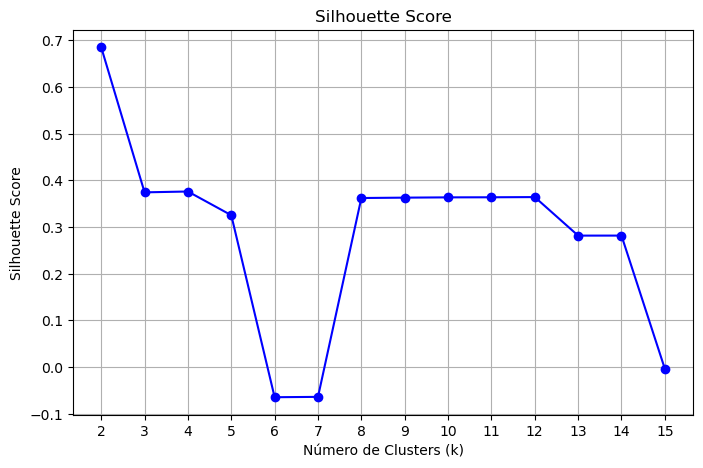

In [16]:
from sklearn.metrics import silhouette_score

def calcular_silhouette_score(matriz, min_k=2, max_k=15):
    #Calcula y guarda el Silhouette Score para diferentes valores de k.
    silhouette_scores = []
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(matriz)
        score = silhouette_score(matriz, labels)
        silhouette_scores.append(score)
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), silhouette_scores, marker='o', color='blue')
    plt.title('Silhouette Score')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(min_k, max_k + 1))
    plt.grid(True)
    plt.show()

calcular_silhouette_score(matriz_normalizada)


k=2 tiene el Silhouette Score más alto (0.6850), lo cual es típico porque agrupar todo en 2 clústeres maximiza la cohesión interna.

Sin embargo, después de k=2, el puntaje es más estable y ligeramente mejor en k=12 (0.3641), aunque las diferencias en los valores para k=8 a 12 son mínimas.

La elección entre k=2 (alta separación con menor granularidad) y k=12 (balance razonable) dependerá del nivel de detalle que se busque en las recomendaciones

Puesto que Tanto el método del codo como el de Silhouette coinden ambos en que K=8 es un buen candidato, `nos quedaremos con 8 clusters.`

## IMPLEMENTACIÓN KMEANS

Lo primero que tenemos que hacer para implementar Kmeans es decidir que tipo de agrupación de clusteres vamos a realizar, si clusteres de usuarios similares, o clusteres de películas. En este caso como disponemos de menos usuarios que películas los clusteres serán de usuarios, esto se hace así porque 610 usuarios son mucho mas manejables que 9270 películas, Kmeans será mas eficiente y rápido con menos filas (usuarios) en la matriz.



Implementaré Kmeans con la distancia del Coseno, puesto que esta distancia no viene directamente con el Kmenas habrá que calcular la distancia de coseno a parte.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.cluster import KMeans
import os


In [7]:
def calcular_distancia_coseno(matriz_normalizada, archivo_salida='distancia_coseno.npy'):
    if os.path.exists(archivo_salida):
        # Cargar desde archivo si existe
        distancia_coseno = np.load(archivo_salida)
    else:
        # Calcular la similitud coseno y la distancia si el archivo no existe
        similitud_coseno = cosine_similarity(matriz_normalizada)
        distancia_coseno = 1 - similitud_coseno  # Convertir la similitud coseno en distancia coseno
        
        np.save(archivo_salida, distancia_coseno)
        print(f"Matriz de distancia coseno guardada en '{archivo_salida}'")

    return distancia_coseno


In [8]:
distancia_coseno = calcular_distancia_coseno(matriz_normalizada)

In [9]:
modelo_kmeans = KMeans(n_clusters=8, random_state=42)
clusters_usuarios = modelo_kmeans.fit_predict(distancia_coseno)

## CALIDAD DEL CLÚSTER

Ahora miraremos que la distribución de los clústeres sea correcta

In [10]:
# Contar el número de usuarios por cluster
distribucion_clusters = pd.DataFrame(clusters_usuarios, columns=['Cluster'])
print(distribucion_clusters['Cluster'].value_counts())


Cluster
5    118
6    105
3     89
1     88
7     88
2     60
0     40
4     22
Name: count, dtype: int64


Los clústeres parecen prometedores, pero vamos a ver las películas promedio más calificadas por los usuarios de cada clúster para ver si existen patrones específicos

In [11]:
# Agregar los clusters a la matriz normalizada
matriz_normalizada['cluster'] = clusters_usuarios

# Calcular la calificación promedio por cluster
peliculas_por_cluster = matriz_normalizada.groupby('cluster').mean()

# Mostrar las 5 películas más populares por cluster
for cluster in range(8):
    print(f"\nPelículas más populares en el cluster {cluster}:")
    print(peliculas_por_cluster.loc[cluster].sort_values(ascending=False).head(5))



Películas más populares en el cluster 0:
movieId
110    0.994783
318    0.854707
356    0.816204
457    0.785685
150    0.644245
Name: 0, dtype: float64

Películas más populares en el cluster 1:
movieId
260     0.825781
2571    0.561195
1196    0.535617
4993    0.501628
1198    0.498329
Name: 1, dtype: float64

Películas más populares en el cluster 2:
movieId
296    0.689634
593    0.655096
318    0.632916
356    0.624627
50     0.466312
Name: 2, dtype: float64

Películas más populares en el cluster 3:
movieId
60069    0.108852
2571     0.102586
4896     0.100946
8368     0.100171
5816     0.100102
Name: 3, dtype: float64

Películas más populares en el cluster 4:
movieId
593    1.314724
296    1.256327
318    1.143587
527    0.908327
356    0.848707
Name: 4, dtype: float64

Películas más populares en el cluster 5:
movieId
296     0.386359
858     0.376550
2858    0.284068
1193    0.262993
608     0.261445
Name: 5, dtype: float64

Películas más populares en el cluster 6:
movieId
356   

 La lista de películas más populares dentro de cada cluster refleja que los grupos tienen preferencias diferenciadas. Esto es un indicador de que el clustering está capturando patrones útiles para la personalización.

 Por ejemplo la película con el id 318 que correponde a "Shawshank Redemption, The (1994) con el genero de Crimen/Drama" demuestra ser puntuada de manera muy diferente dependiendo del clúster, esto da a entender que dependiendo del clúster también existe una preferencia u otra sobre los diferentes géneros que hay.

 A continuación vamos a visualizar esos clústeres:

##  VISUALIZACIÓN

In [12]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.spatial import ConvexHull
import numpy as np

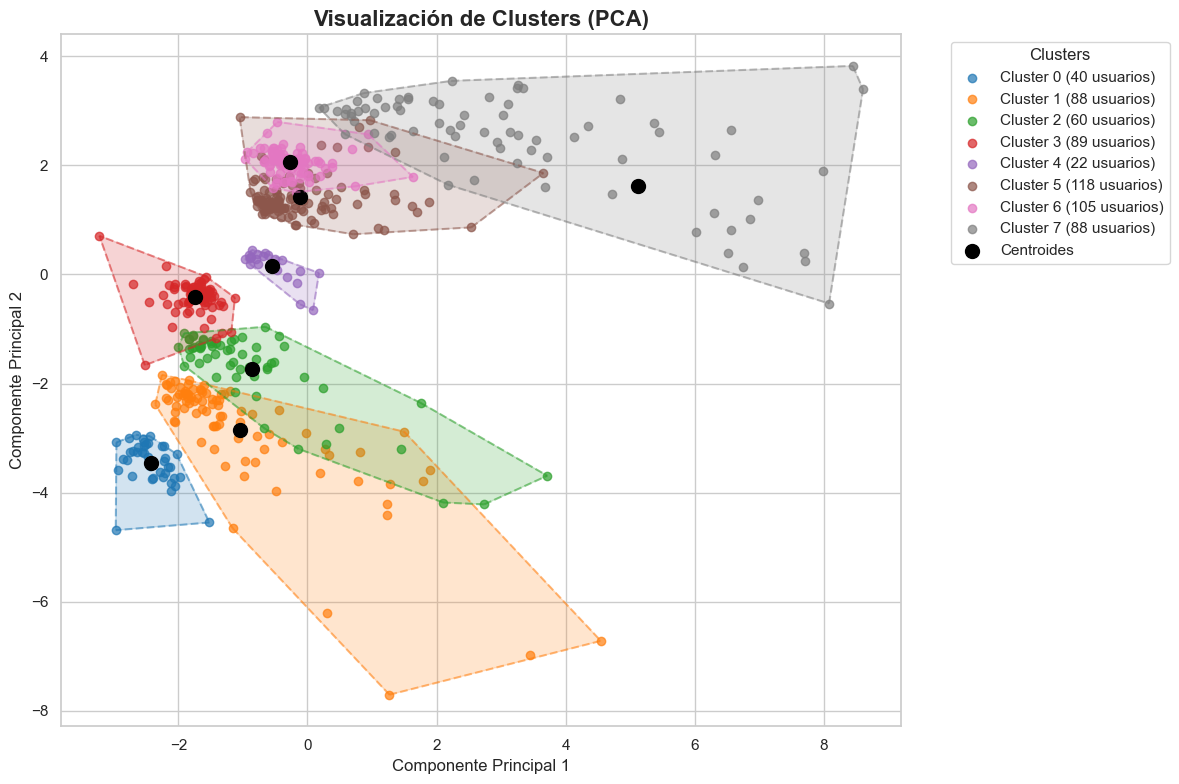

In [66]:
# Reducir la dimensionalidad a 2 componentes principales
matriz_normalizada_visualizacion = matriz_normalizada.copy()
matriz_normalizada_visualizacion.columns = matriz_normalizada_visualizacion.columns.astype(str)

# Aplicar PCA
pca = PCA(n_components=2)
matriz_reducida = pca.fit_transform(matriz_normalizada_visualizacion)

df_clusters = pd.DataFrame({
    'Componente_1': matriz_reducida[:, 0],
    'Componente_2': matriz_reducida[:, 1],
    'Cluster': clusters_usuarios
})


umbral_x_min = -10
umbral_x_max = 10
umbral_y_min = -10
umbral_y_max = 10


df_clusters_filtrado = df_clusters[
    (df_clusters['Componente_1'] >= umbral_x_min) & 
    (df_clusters['Componente_1'] <= umbral_x_max) & 
    (df_clusters['Componente_2'] >= umbral_y_min) & 
    (df_clusters['Componente_2'] <= umbral_y_max)
]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))
for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
    datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
    puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    
    if len(puntos) > 2:  
        hull = ConvexHull(puntos)
        for simplex in hull.simplices:
            plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=0.5, linestyle='--')
        plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
    
    plt.scatter(
        datos_cluster_filtrado['Componente_1'], 
        datos_cluster_filtrado['Componente_2'], 
        label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
        alpha=0.7, 
        color=color
    )

centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
plt.scatter(
    centroides['Componente_1'], 
    centroides['Componente_2'], 
    s=100, 
    c='black', 
    marker='o', 
    label='Centroides'
)


plt.title('Visualización de Clusters (PCA)', fontsize=16, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando los Componentes Principales. Los componentes principales son combinaciones lineales de las calificaciones originales que capturan la mayor parte de la variabilidad en los datos.

El Primer Componente Principal (PC1) explica la mayor cantidad de variación en las calificaciones, mientras que el Segundo Componente Principal (PC2) captura la siguiente mayor variabilidad, siendo ambos ortogonales entre sí. Los clusters muestran agrupaciones de usuarios con patrones similares de calificación, la distancia que existe entre estos a parte de por las calificaciones promedio puede ser debida a la preferencia de géneros

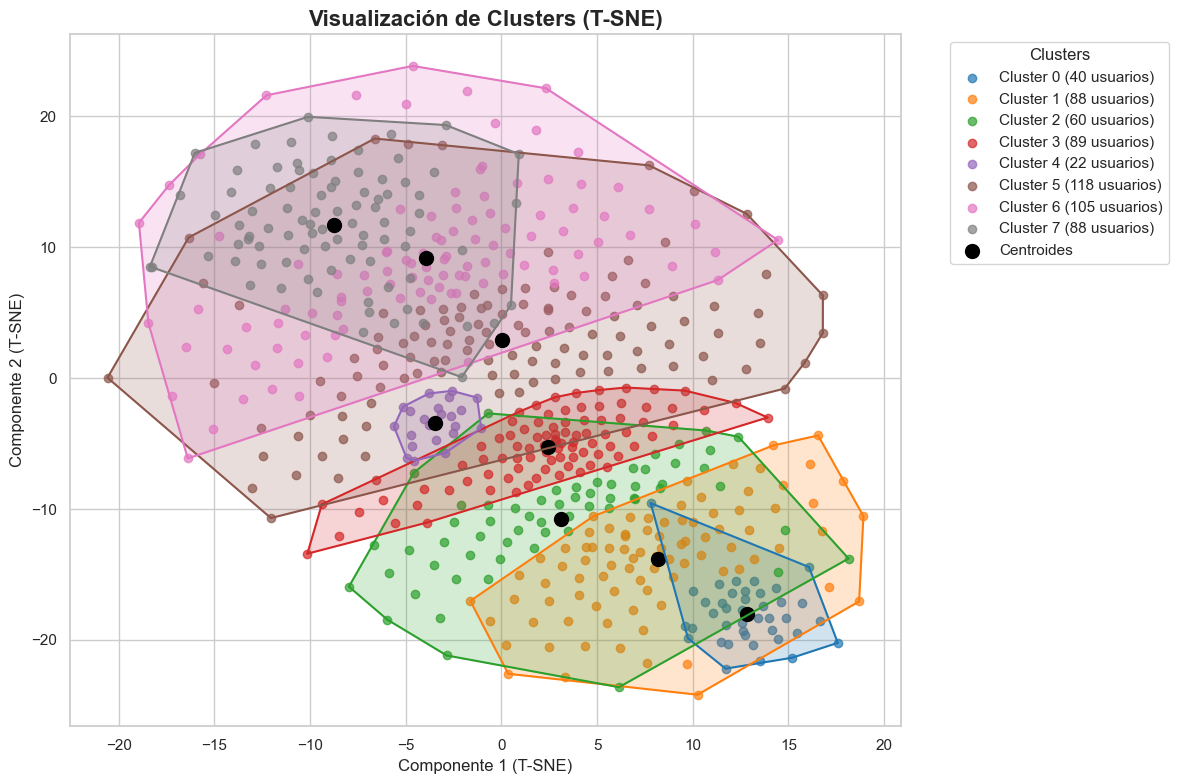

In [67]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
matriz_reducida = tsne.fit_transform(matriz_normalizada_visualizacion)

df_clusters = pd.DataFrame({
    'Componente_1': matriz_reducida[:, 0],
    'Componente_2': matriz_reducida[:, 1],
    'Cluster': clusters_usuarios
})

umbral_x_min = -50
umbral_x_max = 50
umbral_y_min = -50
umbral_y_max = 50

df_clusters_filtrado = df_clusters[
    (df_clusters['Componente_1'] >= umbral_x_min) & 
    (df_clusters['Componente_1'] <= umbral_x_max) & 
    (df_clusters['Componente_2'] >= umbral_y_min) & 
    (df_clusters['Componente_2'] <= umbral_y_max)
]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))


colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))


for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
    datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
    puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    

    if len(puntos) > 2: 
        hull = ConvexHull(puntos)
        for simplex in hull.simplices:
            plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=1, linestyle='-')
        plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
    

    plt.scatter(
        datos_cluster_filtrado['Componente_1'], 
        datos_cluster_filtrado['Componente_2'], 
        label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
        alpha=0.7, 
        color=color
    )

centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
plt.scatter(
    centroides['Componente_1'], 
    centroides['Componente_2'], 
    s=100, 
    c='black', 
    marker='o', 
    label='Centroides'
)

plt.title('Visualización de Clusters (T-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('Componente 1 (T-SNE)', fontsize=12)
plt.ylabel('Componente 2 (T-SNE)', fontsize=12)
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando T-SNE (t-Distributed Stochastic Neighbor Embedding). A diferencia de PCA, T-SNE captura relaciones no lineales entre las calificaciones y distribuye los datos de forma que los usuarios similares se agrupan de manera más intuitiva. Los ejes no representan variabilidad específica como en PCA, sino una transformación que busca mantener la proximidad relativa de los puntos en el espacio original.

## PREDICCIONES DE PRUEBA

## `ESTO DE AQUI NO FUNCIONA DE MOMENTO, FALTA REESCALAR Y EVALUAR`

Para poder llevar a cabo las predicciones tenemos que seguir los siguientes pasos:

Paso 1: Utilizar la matriz de distancia coseno

In [13]:
distancia_coseno = calcular_distancia_coseno(matriz_normalizada)

Paso 2: Encontrar el cluster del usuario \
Ejemplo: Usuario 26

In [14]:
usuario_id = 25
cluster_usuario = clusters_usuarios[usuario_id]
print(f"Cluster del usuario con ID {usuario_id}: {cluster_usuario}")

Cluster del usuario con ID 25: 4


Paso 3:Encontrar los usuarios más similares dentro del mismo cluster\
Filtra los usuarios del mismo cluster:

In [15]:
usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
print(f"Usuarios en el mismo cluster: {usuarios_en_cluster}")

Usuarios en el mismo cluster: [ 25  53 101 108 116 132 133 141 241 352 372 385 443 445 454 511 564 565
 587 588 601 608]


Encuentra a los usuarios más similares dentro de este cluster:\
Ej 3 clusteres similares

In [16]:
distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
k = 3  # Número de usuarios similares a considerar
usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo
print(f"Usuarios más similares: {usuarios_similares}")


Usuarios más similares: [511 565 587]


Paso 4: Filtrar las películas no vistas

Para cada usuario similar, vamos a comprobar qué películas ha visto y que el usuario objetivo no ha visto. Para esto, puedes usar una estructura booleana que indique qué películas han sido vistas o no.

In [17]:
peliculas_vistas_usuario = matriz_normalizada.iloc[usuario_id] > 0  # Calificación > 0 significa que fue vista
peliculas_no_vistas = ~peliculas_vistas_usuario
print(peliculas_no_vistas)


movieId
1           True
2           True
3           True
4           True
5           True
           ...  
193583      True
193585      True
193587      True
193609      True
cluster    False
Name: 26, Length: 9725, dtype: bool


Paso 5: Calcular las películas recomendadas


Ahora que sabemos qué películas podrían ser relevantes, calculamos las películas recomendadas basándonos en la calificación promedio de los usuarios similares.

Calcular la popularidad de cada película en base a los usuarios similares:

In [18]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    # Reescalar a los valores originales
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    # Asegurarse de que están dentro del rango
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

In [19]:
calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
predicciones = calificacion_promedio_similares[peliculas_no_vistas]

# Reescalar las predicciones al rango original
media_usuario = matriz_usuario_pelicula.iloc[usuario_id].mean()
std_usuario = matriz_usuario_pelicula.iloc[usuario_id].std()
predicciones_reescaladas = reescalar_predicciones(predicciones, media_usuario, std_usuario)

Recomendar las películas más populares que el usuario no ha visto:

In [20]:
# Obtener las N mejores películas recomendadas
N = 10
peliculas_recomendadas = predicciones_reescaladas.sort_values(ascending=False).head(N)
print("Películas recomendadas:")
print(peliculas_recomendadas)

Películas recomendadas:
movieId
318    4.164435
110    4.164435
50     4.164435
527    3.967270
356    3.770105
32     3.614371
151    3.614371
778    3.583134
6      3.583134
223    3.583134
dtype: float64


Parece que recomienda correctamente las películas, vamos a unir todos los pasos en una misma funcion, a realizar algunas pruebas y finalmente a validar el algoritmo para ver si está dando resultados satisfactorios

In [21]:
def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    # Reescalar a los valores originales
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    # Asegurarse de que están dentro del rango
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

def recomendar_peliculas_usuario_especifico(modelo_kmeans, matriz_normalizada, usuario_id, N=5):
    """
    Genera las N mejores recomendaciones de películas para un usuario específico.

    Parámetros:
    - modelo_kmeans: Modelo KMeans entrenado.
    - clusters_usuarios: Array con los clústeres asignados a cada usuario.
    - matriz_normalizada: DataFrame de la matriz usuario-película normalizada.
    - usuario_id: ID del usuario objetivo (índice de la matriz).
    - N: Número de películas a recomendar (default: 5).

    Retorna:
    - Pandas Series con las N mejores recomendaciones y sus puntuaciones.
    """
    # Paso 1: Identificar el clúster del usuario objetivo
    clusters_usuarios = modelo_kmeans.fit_predict(distancia_coseno)
    cluster_usuario = clusters_usuarios[usuario_id]

    # Paso 2: Filtrar usuarios en el mismo clúster
    usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]

    # Paso 3: Calcular las distancias a otros usuarios en el clúster
    distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
    k = 3  # Número de usuarios similares a considerar
    usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir el usuario objetivo

    # Paso 4: Filtrar películas no vistas por el usuario objetivo
    peliculas_vistas_usuario = matriz_normalizada.iloc[usuario_id] > 0  # Calificación > 0 indica vista
    peliculas_no_vistas = ~peliculas_vistas_usuario

    # Paso 5: Calcular la predicción promedio para las películas no vistas
    calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
    calificacion_promedio_similares = calificaciones_similares.mean(axis=0)
    predicciones = calificacion_promedio_similares[peliculas_no_vistas]

    # Paso 6: Reescalar las predicciones al rango original [0.5, 5.0]
    predicciones_reescaladas = reescalar_predicciones(
        predicciones, 
        matriz_usuario_pelicula.iloc[usuario_id].mean(), 
        matriz_usuario_pelicula.iloc[usuario_id].std()
    )

    # Paso 7: Seleccionar las N mejores películas
    peliculas_recomendadas = predicciones_reescaladas.sort_values(ascending=False).head(N)

    return peliculas_recomendadas


Vamos a recomendar las peliculas para el usuario 441, que tiene la media mas baja de todas (1.27)

In [22]:
usuario_id = 441
N = 10
recomendaciones = recomendar_peliculas_usuario_especifico(modelo_kmeans, matriz_normalizada, usuario_id, N)

# Mostrar resultados
print(f"Recomendaciones para el usuario {usuario_id}:")
print(recomendaciones)

Recomendaciones para el usuario 441:
movieId
527      2.071204
2959     1.894580
3087     1.783626
785      1.627178
277      1.566835
1125     1.566835
2762     1.566835
1210     1.566835
6377     1.542402
37729    1.542402
dtype: float64


Vamos a ver si el centroide que se le ha asignado es correcto

El centroide asignado es correcto, pero hay que evaluar algunas cosas mas:

- Si el centroide está asignado correctamente
- La media de valoraciones original (para ver la derencia con la predicha)
- La media de valoraciones predicha

## `REVISAR`

In [65]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
def analizar_usuario_completo(usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula, movies_csv, N=5):
    """
    Analiza completamente un usuario, mostrando su clúster asignado, similitud con el clúster,
    el clúster más cercano, y las medias de valoraciones originales y predichas.

    Parámetros:
    - usuario_id: ID del usuario a analizar.
    - modelo_kmeans: Modelo KMeans entrenado.
    - distancia_coseno: Matriz de distancias coseno.
    - matriz_usuario_pelicula: Matriz original de calificaciones (usuarios x películas).
    - movies_csv: Path al archivo movies.csv que contiene los títulos de las películas.
    - N: Número de recomendaciones a considerar (default: 5).

    Retorna:
    - Diccionario con el análisis del usuario.
    """
    # 1. Clúster asignado por KMeans
    cluster_asignado = clusters_usuarios[usuario_id]

    # 2. Similitud con el clúster asignado
    distancias_a_centroides = cosine_similarity(
        distancia_coseno[usuario_id].reshape(1, -1), modelo_kmeans.cluster_centers_
    )[0]
    similitud_actual = distancias_a_centroides[cluster_asignado]

    # 3. Clúster más cercano basado en distancia coseno
    cluster_mas_cercano = np.argmax(distancias_a_centroides)
    similitud_cercana = distancias_a_centroides[cluster_mas_cercano]

    # 4. Media de valoraciones originales del usuario
    media_calificaciones_usuario = matriz_usuario_pelicula.iloc[usuario_id].mean()

    # 5. Predicciones de calificaciones
    k = 5  # Número de usuarios similares
    usuarios_similares = np.argsort(distancia_coseno[usuario_id])[1:k+1]
    similitudes_coseno = 1 - distancia_coseno[usuario_id]  # Convertir distancia a similitud
    calificaciones_similares = matriz_usuario_pelicula.iloc[usuarios_similares]
    pesos = similitudes_coseno[usuarios_similares]
    pesos_normalizados = pesos / pesos.sum()
    calificaciones_ponderadas = (calificaciones_similares.T * pesos_normalizados).sum(axis=1)

    # Filtrar películas no vistas por el usuario
    peliculas_no_vistas = matriz_usuario_pelicula.iloc[usuario_id].isna()
    predicciones_no_vistas = calificaciones_ponderadas[peliculas_no_vistas]

    # Obtener las N mejores recomendaciones
    peliculas_recomendadas = predicciones_no_vistas.sort_values(ascending=False).head(N)
    mejores_recomendaciones_ids = peliculas_recomendadas.index.tolist()
    mejores_recomendaciones_valores = peliculas_recomendadas.values.tolist()

    # Cargar movies.csv y agregar nombres
    movies = pd.read_csv(movies_csv)
    peliculas_con_titulos = movies[movies['movieId'].isin(mejores_recomendaciones_ids)][['movieId', 'title']]
    peliculas_con_titulos = peliculas_con_titulos.set_index('movieId').reindex(mejores_recomendaciones_ids)
    peliculas_con_titulos['Predicted Rating'] = mejores_recomendaciones_valores

    # Media de las recomendaciones
    media_recomendaciones = peliculas_recomendadas.mean()

    # 6. Resultado consolidado
    resultado = {
        "Usuario": usuario_id,
        "Cluster asignado": cluster_asignado,
        "Similitud con cluster asignado": similitud_actual,
        "Cluster más cercano": cluster_mas_cercano,
        "Similitud con cluster más cercano": similitud_cercana,
        "Correctamente asignado": cluster_asignado == cluster_mas_cercano,
        "Media valoraciones originales": media_calificaciones_usuario,
        "Media valoraciones predichas": media_recomendaciones,
        "Top N Recomendaciones": peliculas_con_titulos.reset_index(),
    }

    # Imprimir análisis coherente
    print(f"\n--- Análisis del Usuario {usuario_id} ---")
    print(f"Cluster asignado: {cluster_asignado}")
    print(f"Similitud con el cluster asignado: {similitud_actual:.4f}")
    print(f"Cluster más cercano en distancia coseno: {cluster_mas_cercano} (Similitud: {similitud_cercana:.4f})")
    print(f"¿Correctamente asignado? {'Sí' if resultado['Correctamente asignado'] else 'No'}")
    print(f"Media de valoraciones originales: {media_calificaciones_usuario:.4f}")
    print(f"Media de valoraciones predichas: {media_recomendaciones:.4f}")
    print(f"\nTop {N} Recomendaciones (Título - Valor):")
    for _, row in peliculas_con_titulos.iterrows():
        print(f"  Película: {row['title']} - Predicted Rating: {row['Predicted Rating']:.4f}")

    return resultado


In [181]:
ruta_nombres_peliculas = "BBDD_100K/movies.csv"
usuario_id = 441
analisis_usuario = analizar_usuario_completo(
    usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula,ruta_nombres_peliculas, N=5
)


--- Análisis del Usuario 441 ---
Cluster asignado: 6
Similitud con el cluster asignado: 0.9990
Cluster más cercano en distancia coseno: 6 (Similitud: 0.9990)
¿Correctamente asignado? Sí
Media de valoraciones originales: 1.2750
Media de valoraciones predichas: 1.6918

Top 5 Recomendaciones (Título - Valor):
  Película: Braveheart (1995) - Predicted Rating: 1.8845
  Película: Schindler's List (1993) - Predicted Rating: 1.7047
  Película: Fugitive, The (1993) - Predicted Rating: 1.6975
  Película: Man on the Moon (1999) - Predicted Rating: 1.6017
  Película: Dances with Wolves (1990) - Predicted Rating: 1.5705


In [184]:
usuario_id = 300
analisis_usuario = analizar_usuario_completo(
    usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula,ruta_nombres_peliculas, N=5
)


--- Análisis del Usuario 300 ---
Cluster asignado: 5
Similitud con el cluster asignado: 0.9984
Cluster más cercano en distancia coseno: 5 (Similitud: 0.9984)
¿Correctamente asignado? Sí
Media de valoraciones originales: 3.3202
Media de valoraciones predichas: 2.7921

Top 5 Recomendaciones (Título - Valor):
  Película: Lord of the Rings: The Return of the King, The (2003) - Predicted Rating: 2.9184
  Película: Matrix, The (1999) - Predicted Rating: 2.8115
  Película: Shawshank Redemption, The (1994) - Predicted Rating: 2.7885
  Película: Lord of the Rings: The Fellowship of the Ring, The (2001) - Predicted Rating: 2.7210
  Película: Lord of the Rings: The Two Towers, The (2002) - Predicted Rating: 2.7210


In [185]:
usuario_id = 6
analisis_usuario = analizar_usuario_completo(
    usuario_id, modelo_kmeans, distancia_coseno, matriz_usuario_pelicula,ruta_nombres_peliculas, N=5
)


--- Análisis del Usuario 6 ---
Cluster asignado: 1
Similitud con el cluster asignado: 0.9988
Cluster más cercano en distancia coseno: 1 (Similitud: 0.9988)
¿Correctamente asignado? Sí
Media de valoraciones originales: 3.2303
Media de valoraciones predichas: 3.6418

Top 5 Recomendaciones (Título - Valor):
  Película: Pulp Fiction (1994) - Predicted Rating: 3.9019
  Película: Matrix, The (1999) - Predicted Rating: 3.8124
  Película: Fight Club (1999) - Predicted Rating: 3.7834
  Película: Shawshank Redemption, The (1994) - Predicted Rating: 3.5965
  Película: Schindler's List (1993) - Predicted Rating: 3.1146


La diferencia aparente es similar al algoritmo KNN, vamos a hacer la evaluación completa para ver los resultados

## EVALUACIÓN

In [23]:
def peliculas_del_usuario(usuario, matriz_usuario_pelicula):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_usuario_pelicula.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales

In [82]:
def calcular_accuracy(usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k=5):
    """
    Calcula RMSE, MAE y Accuracy para un usuario dado, prediciendo únicamente las películas ya valoradas.
    """
    # 1. Obtener las películas valoradas por el usuario y sus valoraciones originales
    peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario_id, matriz_usuario_pelicula)
    
    # 2. Identificar el cluster del usuario y los usuarios similares
    cluster_usuario = clusters_usuarios[usuario_id]
    usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
    distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
    
    # Seleccionar los usuarios más similares dentro del cluster
    usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo

    # 3. Obtener las calificaciones normalizadas de los usuarios similares
    calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
    calificacion_promedio_similares = calificaciones_similares.mean(axis=0)

    # 4. Predicciones para las películas ya valoradas
    predicciones_normalizadas = calificacion_promedio_similares[peliculas_valoradas]

    # 5. Reescalar las predicciones al rango original
    media_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().mean()
    std_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().std()
    predicciones_reescaladas = reescalar_predicciones(
        np.array(predicciones_normalizadas), 
        media_usuario, 
        std_usuario
    )

    # 6. Calcular métricas
    # RMSE y MAE
    rmse = np.sqrt(mean_squared_error(valoraciones_originales, predicciones_reescaladas))
    mae = mean_absolute_error(valoraciones_originales, predicciones_reescaladas)
    
    # Accuracy
    accuracy = np.mean(1 - np.abs((np.array(predicciones_reescaladas) - np.array(valoraciones_originales)) / np.array(valoraciones_originales)))
    
    return {"user_id": usuario_id, "rmse": rmse, "mae": mae, "accuracy": accuracy}

# 7. Calcular para múltiples usuarios y consolidar resultados
def calcular_accuracy_global(num_usuarios, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k=5):
    """
    Calcula las métricas (RMSE, MAE y Accuracy) para los primeros num_usuarios.
    """
    # Crear lista de usuarios del 1 al número especificado
    usuarios = list(range(1, num_usuarios + 1))
    
    resultados = []
    for usuario_id in usuarios:
        resultado_usuario = calcular_accuracy(
            usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k
        )
        resultados.append(resultado_usuario)
    
    resultados_df = pd.DataFrame(resultados)
    rmse_promedio = resultados_df["rmse"].mean()
    mae_promedio = resultados_df["mae"].mean()
    accuracy_promedio = resultados_df["accuracy"].mean()
    
    print(f"RMSE promedio: {rmse_promedio:.4f}")
    print(f"MAE promedio: {mae_promedio:.4f}")
    print(f"Accuracy promedio: {accuracy_promedio*100:.4f}%" )
    return resultados_df


def reescalar_predicciones(predicciones_normalizadas, media_usuario, std_usuario, min_val=0.5, max_val=5.0):
    # Reescalar a los valores originales
    predicciones_reescaladas = (predicciones_normalizadas * std_usuario) + media_usuario
    # Asegurarse de que están dentro del rango
    predicciones_reescaladas = np.clip(predicciones_reescaladas, min_val, max_val)
    return predicciones_reescaladas

In [84]:
num_usuarios = 609
resultados_df = calcular_accuracy_global(
    num_usuarios, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, k=5
)


RMSE promedio: 1.0355
MAE promedio: 0.8503
Accuracy promedio: 62.1843%


Puesto que el Kmeans implementa utiliza unicamente los usuarios mas similares del clúster para las predicciones, es posible que algunos usuarios no estén bien asignados y tengan accuracys muy por debajo de donde deberían, pero gracias a este proceso la ejecución es extremadamente rápida, ya que solo se está comparando el algoritmo con los 5 usuarios mas similares de dentro del cluster.

Esto da la posibilidad de uso de la `factorización ponderada de matrices`, ya que el tiempo de ejecución es muy rápido

Por otro lado también es posible realizar un proceso de reasignación del usuario, para verificar que el accuracy conseguido es realmente el mejor

## REASIGNACIÓN DEL USUARIO

In [91]:
def calcular_accuracy_y_reasignar(
    usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k=5, predicciones_df=None
):
    """
    Calcula el Accuracy para un usuario dado. Si el Accuracy es inferior al 50%, reasigna el usuario a otro cluster.
    Guarda las predicciones en un DataFrame predicciones_df.
    """
    # Mantener un registro de clusters visitados
    clusters_visitados = set()

    while True:
        # 1. Obtener las películas valoradas por el usuario y sus valoraciones originales
        peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario_id, matriz_usuario_pelicula)
        print(f"\nUsuario {usuario_id}: Películas valoradas: {len(peliculas_valoradas)}")

        # 2. Identificar el cluster del usuario y los usuarios similares
        cluster_usuario = clusters_usuarios[usuario_id]
        print(f"Usuario {usuario_id}: Actualmente en el cluster {cluster_usuario}")
        
        usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
        distancias_cluster = distancia_coseno[usuario_id, usuarios_en_cluster]
        print(f"Usuario {usuario_id}: Número de usuarios en el mismo cluster: {len(usuarios_en_cluster)}")

        # Seleccionar los usuarios más similares dentro del cluster
        usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluir usuario objetivo
        print(f"Usuario {usuario_id}: Usuarios más similares seleccionados: {usuarios_similares}")

        # 3. Obtener las calificaciones normalizadas de los usuarios similares
        calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
        calificacion_promedio_similares = calificaciones_similares.mean(axis=0)

        # 4. Predicciones para las películas ya valoradas
        predicciones_normalizadas = calificacion_promedio_similares[peliculas_valoradas]

        # 5. Reescalar las predicciones al rango original
        media_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().mean()
        std_usuario = matriz_usuario_pelicula.loc[usuario_id].dropna().std()
        predicciones_reescaladas = reescalar_predicciones(
            np.array(predicciones_normalizadas), 
            media_usuario, 
            std_usuario
        )

        # Guardar las predicciones en el DataFrame
        if predicciones_df is not None:
            for pelicula, prediccion in zip(peliculas_valoradas, predicciones_reescaladas):
                predicciones_df.loc[usuario_id, pelicula] = prediccion

        # 6. Calcular Accuracy usando la lógica de KNN
        accuracies_individuales = []
        for valoracion, prediccion in zip(valoraciones_originales, predicciones_reescaladas):
            if valoracion != 0:  # Evitar divisiones por cero
                accuracy_individual = 1 - abs(valoracion - prediccion) / valoracion
                accuracies_individuales.append(accuracy_individual)

        accuracy_promedio = (sum(accuracies_individuales) / len(accuracies_individuales)) * 100 if accuracies_individuales else 0
        print(f"Usuario {usuario_id}: Accuracy inicial: {accuracy_promedio:.2f}%")

        # Si el accuracy es suficiente, detener el ciclo
        if accuracy_promedio >= 50.0:
            return {"user_id": usuario_id, "accuracy": accuracy_promedio}

        print(f"Usuario {usuario_id}: Accuracy {accuracy_promedio:.2f}% < 85.0%. Reasignando a otro cluster.")

        # Calcular distancias del usuario al centro de cada cluster
        distancias_a_clusters = modelo_kmeans.transform(distancia_coseno)[usuario_id]
        print(f"Usuario {usuario_id}: Distancias a clusters: {distancias_a_clusters}")

        # Ordenar los clusters por distancia, excluir el actual y los ya visitados
        clusters_visitados.add(cluster_usuario)
        clusters_ordenados = [c for c in np.argsort(distancias_a_clusters) if c not in clusters_visitados]

        # Si no hay más clusters para reasignar, salir del ciclo
        if not clusters_ordenados:
            print(f"Usuario {usuario_id}: No hay más clusters disponibles para reasignar.")
            return {"user_id": usuario_id, "accuracy": accuracy_promedio}

        # Reasignar al siguiente cluster más cercano
        siguiente_cluster = clusters_ordenados[0]
        clusters_usuarios[usuario_id] = siguiente_cluster
        print(f"Usuario {usuario_id} reasignado al cluster {siguiente_cluster}.")

def calcular_accuracy_global_y_reasignar(
    num_usuarios, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k=5
):
    """
    Calcula las métricas para los primeros num_usuarios y reasigna usuarios con bajo accuracy a otro cluster.
    """
    # Crear un DataFrame vacío para guardar las predicciones
    predicciones_df = pd.DataFrame(index=matriz_usuario_pelicula.index, columns=matriz_usuario_pelicula.columns)

    usuarios = list(range(1, num_usuarios + 1))
    resultados = []
    for usuario_id in usuarios:
        resultado_usuario = calcular_accuracy_y_reasignar(
            usuario_id, matriz_usuario_pelicula, matriz_normalizada, clusters_usuarios, distancia_coseno, modelo_kmeans, k, predicciones_df
        )
        resultados.append(resultado_usuario)
    
    resultados_df = pd.DataFrame(resultados)
    accuracy_promedio = resultados_df["accuracy"].mean()
    
    print(f"\nAccuracy promedio después de reasignación: {accuracy_promedio:.2f}%")
    return resultados_df, predicciones_df



In [92]:
resultados_df, predicciones_df = calcular_accuracy_global_y_reasignar(
    num_usuarios=609,
    matriz_usuario_pelicula=matriz_usuario_pelicula,
    matriz_normalizada=matriz_normalizada,
    clusters_usuarios=clusters_usuarios,
    distancia_coseno=distancia_coseno,
    modelo_kmeans=modelo_kmeans,
    k=5
)




Usuario 1: Películas valoradas: 29
Usuario 1: Actualmente en el cluster 0
Usuario 1: Número de usuarios en el mismo cluster: 256
Usuario 1: Usuarios más similares seleccionados: [208 325 331 195 536]
Usuario 1: Accuracy inicial: 78.37%

Usuario 2: Películas valoradas: 39
Usuario 2: Actualmente en el cluster 4
Usuario 2: Número de usuarios en el mismo cluster: 151
Usuario 2: Usuarios más similares seleccionados: [440 245 343 432 441]
Usuario 2: Accuracy inicial: -252.06%
Usuario 2: Accuracy -252.06% < 85.0%. Reasignando a otro cluster.
Usuario 2: Distancias a clusters: [1.85792775 1.35090718 1.50736451 1.07737163 2.12846589 1.24115478
 1.21258936 1.70562337]
Usuario 2 reasignado al cluster 3.

Usuario 2: Películas valoradas: 39
Usuario 2: Actualmente en el cluster 3
Usuario 2: Número de usuarios en el mismo cluster: 51
Usuario 2: Usuarios más similares seleccionados: [526 585 344 240 371]
Usuario 2: Accuracy inicial: -255.98%
Usuario 2: Accuracy -255.98% < 85.0%. Reasignando a otro clu